In [1]:
# Importing the libraries
#14065234
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dask.dataframe as dd

In [2]:
# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

In [3]:
# Importing the dataset
dataset = pd.read_csv("/scratch/ope4/MERGE/DEC-04-2024/damage_points_cropped.csv")

# Drop the 'Unnamed: 0' column from the DataFrame
#dataset = dataset.drop(columns=['Unnamed: 0'])

# Check the columns after dropping
print(dataset.columns)

# Drop multiple columns
dataset.drop(['SURVEY_YEAR', 'geom', 'prec', 'tmax', 'tmin'], axis=1, inplace=True)

#dataset = dataset.query('STATUS != 0')

print(dataset.columns)



Index(['LANDSAT_1', 'LANDSAT_2', 'LANDSAT_3', 'LANDSAT_4', 'LANDSAT_5',
       'LANDSAT_6', 'LANDSAT_7', 'LANDSAT_8', 'SURVEY_YEAR', 'prec', 'tmax',
       'tmin', 'geom', 'STATUS'],
      dtype='object')
Index(['LANDSAT_1', 'LANDSAT_2', 'LANDSAT_3', 'LANDSAT_4', 'LANDSAT_5',
       'LANDSAT_6', 'LANDSAT_7', 'LANDSAT_8', 'STATUS'],
      dtype='object')


In [4]:
# Subset the data for class 0
class_0 = dataset[dataset['STATUS'] == 0]

# Filter the data for rows where STATUS is not 0
dataset = dataset[dataset['STATUS'] != 0]

# Randomly sample 3400 rows from class_0
sample_class_0 = class_0.sample(n=23400, random_state=42)  # Set seed for reproducibility

# View or work with the sampled data
print(sample_class_0.head())

# Combine the sampled rows with the filtered data
dataset = pd.concat([sample_class_0, dataset], ignore_index=True)

        LANDSAT_1  LANDSAT_2  LANDSAT_3  LANDSAT_4  LANDSAT_5  LANDSAT_6  \
171523       8271       8430       9082       9366      14007      13470   
114691       7900       8097       8798       8899      13801      11422   
116224       7744       7972       8800       8884      14357      11163   
69890        7668       7890       8536       8321      13236      10603   
261764       8305       8588       9374       9627      15420      12573   

        LANDSAT_7  LANDSAT_8  STATUS  
171523      11501      45346       0  
114691       9826      39858       0  
116224       9507      40149       0  
69890        9247      43064       0  
261764      10485      42017       0  


In [5]:
col_name = 'STATUS'

frequency_table = dataset[col_name].value_counts()

# Display the frequency table
print(frequency_table)

STATUS
1    23933
2    23688
0    23400
Name: count, dtype: int64


In [ ]:
#dataset = dataset.query('STATUS != 0')
#print(dataset)

In [6]:
#dataset = dd.read_csv("/scratch/ope4/MERGE/RF.csv")
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values
print(X)
print(y)

[[ 8271  8430  9082 ... 13470 11501 45346]
 [ 7900  8097  8798 ... 11422  9826 39858]
 [ 7744  7972  8800 ... 11163  9507 40149]
 ...
 [ 8000  8193  8845 ... 13084 11101 45491]
 [ 8282  8643  9478 ... 15308 12882 46559]
 [ 7636  7845  8394 ... 10078  8897 42892]]
[0 0 0 ... 2 2 2]


In [7]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3979, random_state = 1)
print(X_train)
print(X_test)
print(y_train)
print(y_test)

# Shuffle the data manually (if needed)
X_train, y_train = np.random.permutation(X_train), np.random.permutation(y_train)
X_test, y_test = np.random.permutation(X_test), np.random.permutation(y_test)

[[ 8113  8362  9153 ... 12892 10487 40591]
 [ 8176  8518  9509 ... 13872 11816 45748]
 [ 8256  8718  9380 ... 14375 12168 42970]
 ...
 [ 7882  8056  8706 ... 11316  9784 43693]
 [ 8358  8510  9143 ... 13190 11430 47183]
 [ 8558  8921  9815 ... 13496 12162 45473]]
[[ 8726  9146  9884 ... 14166 12530 44920]
 [ 8604  8867  9644 ... 14452 12371 43992]
 [ 7544  7682  8189 ... 10349  8855 42101]
 ...
 [ 7967  8160  8872 ... 12956 10892 43079]
 [ 7953  8249  9134 ... 11926 10359 42064]
 [ 8146  8442  9153 ... 13349 11164 44361]]
[0 0 2 ... 0 2 0]
[0 1 0 ... 1 0 1]


In [8]:
# Check class distributions for each dataset
print("Class distribution in data:")
print(dataset['STATUS'].value_counts())

# Assuming 'y_train' and 'y_test' are NumPy arrays
print("\nClass distribution in y_train:")
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

print("\nClass distribution in y_test:")
unique, counts = np.unique(y_test, return_counts=True)
print(dict(zip(unique, counts)))

Class distribution in data:
STATUS
1    23933
2    23688
0    23400
Name: count, dtype: int64

Class distribution in y_train:
{0: 13923, 1: 14539, 2: 14299}

Class distribution in y_test:
{0: 9477, 1: 9394, 2: 9389}


In [9]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [10]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.datasets import make_hastie_10_2

clf = HistGradientBoostingClassifier(max_iter=100).fit(X_train, y_train)
clf.score(X_test, y_test)

0.33064401981599434

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay

# Generate predictions with the best model
y_pred = clf.predict(X_test)  # Use test features to predict

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)  # Compare true labels with predictions

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[1089 5694 2694]
 [1035 5537 2822]
 [1072 5599 2718]]


In [12]:
# If X is a numpy array, convert it back to a DataFrame
feature_names = ['LANDSAT_1', 'LANDSAT_2', 'LANDSAT_3', 'LANDSAT_4', 'LANDSAT_5', 'LANDSAT_6', 
                 'LANDSAT_7', 'LANDSAT_8']  # Manually specify feature names

#, 'prec', 'tmax', 'tmin'
X = pd.DataFrame(X, columns=feature_names)

In [13]:
from sklearn.inspection import permutation_importance

# Get permutation importance
perm_importance = permutation_importance(clf, X, y, n_repeats=50, random_state=42)

# Display importance
perm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Permutation Importance': perm_importance.importances_mean
})

# Sort by importance
perm_importance_df = perm_importance_df.sort_values(by='Permutation Importance', ascending=False)
print(perm_importance_df)


/home/ope4/.conda/envs/monsoon_env/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
/home/ope4/.conda/envs/monsoon_env/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
/home/ope4/.conda/envs/monsoon_env/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
/home/ope4/.conda/envs/monsoon_env/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
/home/ope4/.conda/envs/monsoon_env/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  

     Feature  Permutation Importance
0  LANDSAT_1                     0.0
1  LANDSAT_2                     0.0
2  LANDSAT_3                     0.0
3  LANDSAT_4                     0.0
4  LANDSAT_5                     0.0
5  LANDSAT_6                     0.0
6  LANDSAT_7                     0.0
7  LANDSAT_8                     0.0


/home/ope4/.conda/envs/monsoon_env/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
/home/ope4/.conda/envs/monsoon_env/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
/home/ope4/.conda/envs/monsoon_env/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(


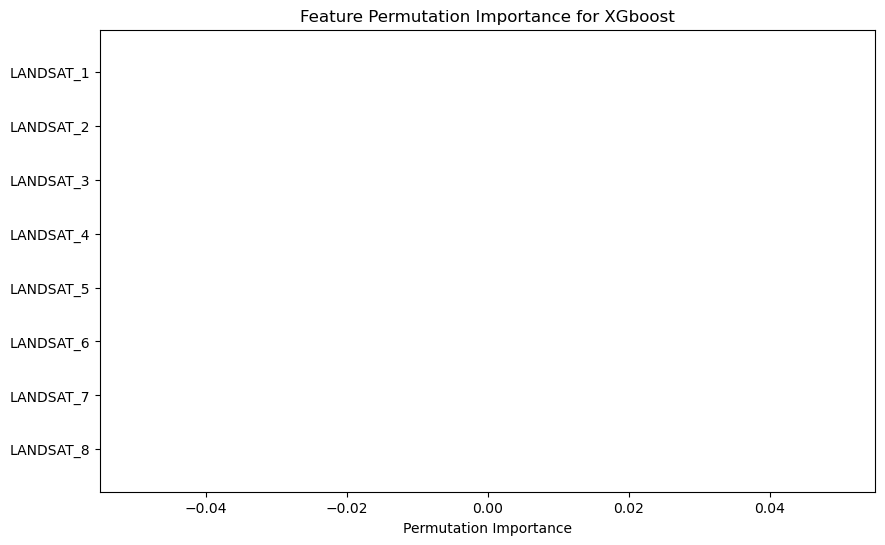

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Create DataFrame
importance_df = pd.DataFrame(perm_importance_df)

# Sort by importance
importance_df = importance_df.sort_values(by='Permutation Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Permutation Importance'], color='skyblue')
plt.xlabel('Permutation Importance')
plt.title('Feature Permutation Importance for XGboost')
plt.gca().invert_yaxis()  # To have the most important feature at the top
plt.show()